# Exploratory Data Analysis: From Raw Data to Hypotheses

Exploratory Data Analysis (EDA) is the process of **understanding a dataset before building a model**.

The objective is not simply to produce many plots.  
A good EDA should progressively answer questions such as:

1. **What data do I have?**
2. **Is the data complete and plausible?**
3. **How are individual variables distributed?**
4. **Which variables appear related?**
5. **Do different groups show different patterns?**
6. **Can we generate hypotheses from what we observe?**
7. **Can dimensionality reduction reveal structure that is difficult to see in the original feature space?**

In this notebook we first use the **Iris dataset** to illustrate a clean EDA workflow, then introduce **PCA** as a natural continuation of multivariate exploration.

## 1. Imports

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Part I — A systematic EDA workflow

## 2. Load the dataset

We start from a small and well-known dataset so that we can focus on the **analysis process** rather than on data cleaning complexity.

The Iris dataset contains four numerical measurements:

- sepal length;
- sepal width;
- petal length;
- petal width;

for three flower species.

In [21]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. First question: what does the dataset look like?

Before plotting anything, inspect the basic structure.

Useful questions:

- How many observations are there?
- How many variables?
- Which variables are numerical?
- Which are categorical?
- Are there missing values?
- Are the values in plausible ranges?

In [22]:
print("Shape:", df.shape)
print()

df.info()

Shape: (150, 5)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.0 KB


In [23]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [24]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


At this stage we are not trying to discover anything sophisticated.

We are simply checking whether the dataset is in a form that makes sense before moving on.

# Part II — Univariate analysis

## 4. Look at one variable at a time

A first useful question is:

> How is each variable distributed?

Histograms help us understand:

- range;
- concentration;
- skewness;
- possible multimodality;
- unusual observations.

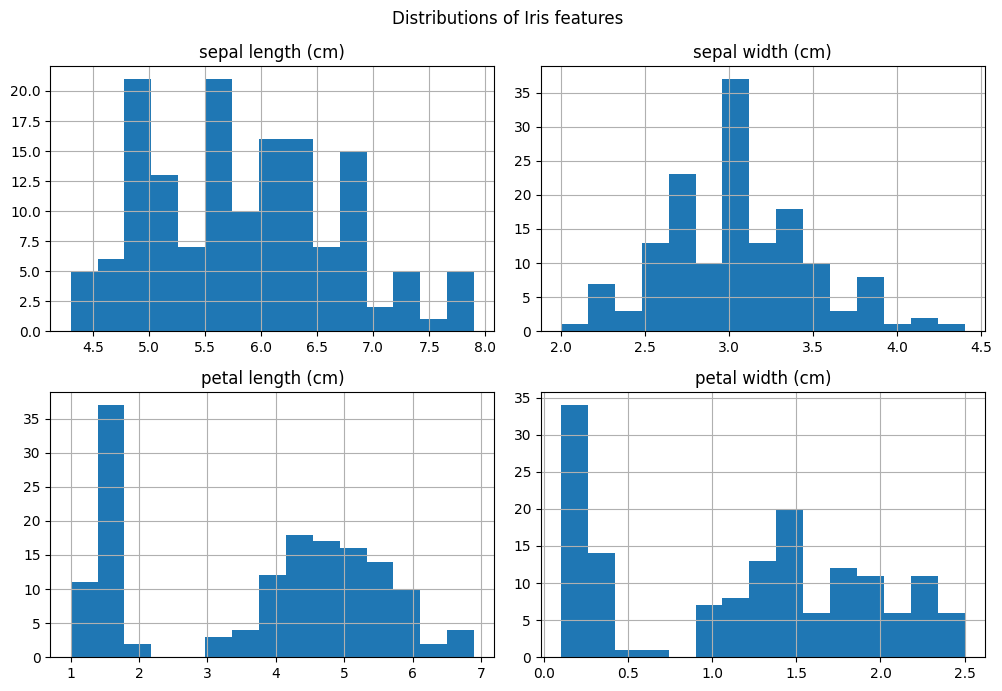

In [25]:
df[iris.feature_names].hist(
    bins=15,
    figsize=(10, 7)
)

plt.suptitle("Distributions of Iris features")
plt.tight_layout()
plt.show()

### Questions to ask

Do the four features have similar distributions?

Can you already see evidence of multiple groups?

Remember that a histogram ignores the class label.  
What looks like a strange or multimodal distribution may actually reflect different populations mixed together.

## 5. Box plots

Box plots provide another view of the distribution.

They summarize:

- median;
- first and third quartiles;
- interquartile range;
- potentially unusual observations.

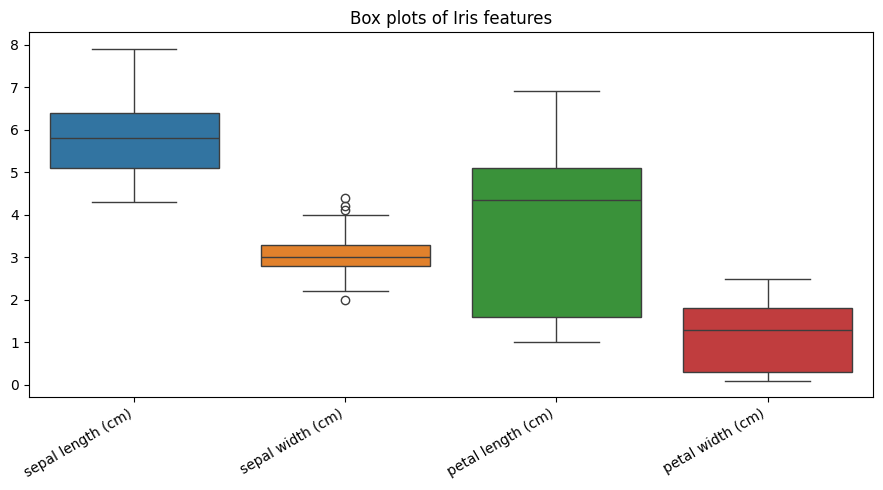

In [26]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df[iris.feature_names]
)

plt.xticks(rotation=30, ha="right")
plt.title("Box plots of Iris features")
plt.tight_layout()
plt.show()

A box plot is useful for identifying values that are unusual **relative to the rest of the sample**.

An apparent outlier is not automatically an error.  
It may be a valid observation and should be interpreted in context.

# Part III — Relationships between variables

## 6. Pairwise relationships

EDA becomes especially informative when we stop looking at variables in isolation.

A **pairplot** simultaneously shows:

- the distribution of each variable on the diagonal;
- scatter plots for every pair of numerical variables;
- group structure when points are colored by class.

This is often one of the fastest ways to understand a small multivariate dataset.

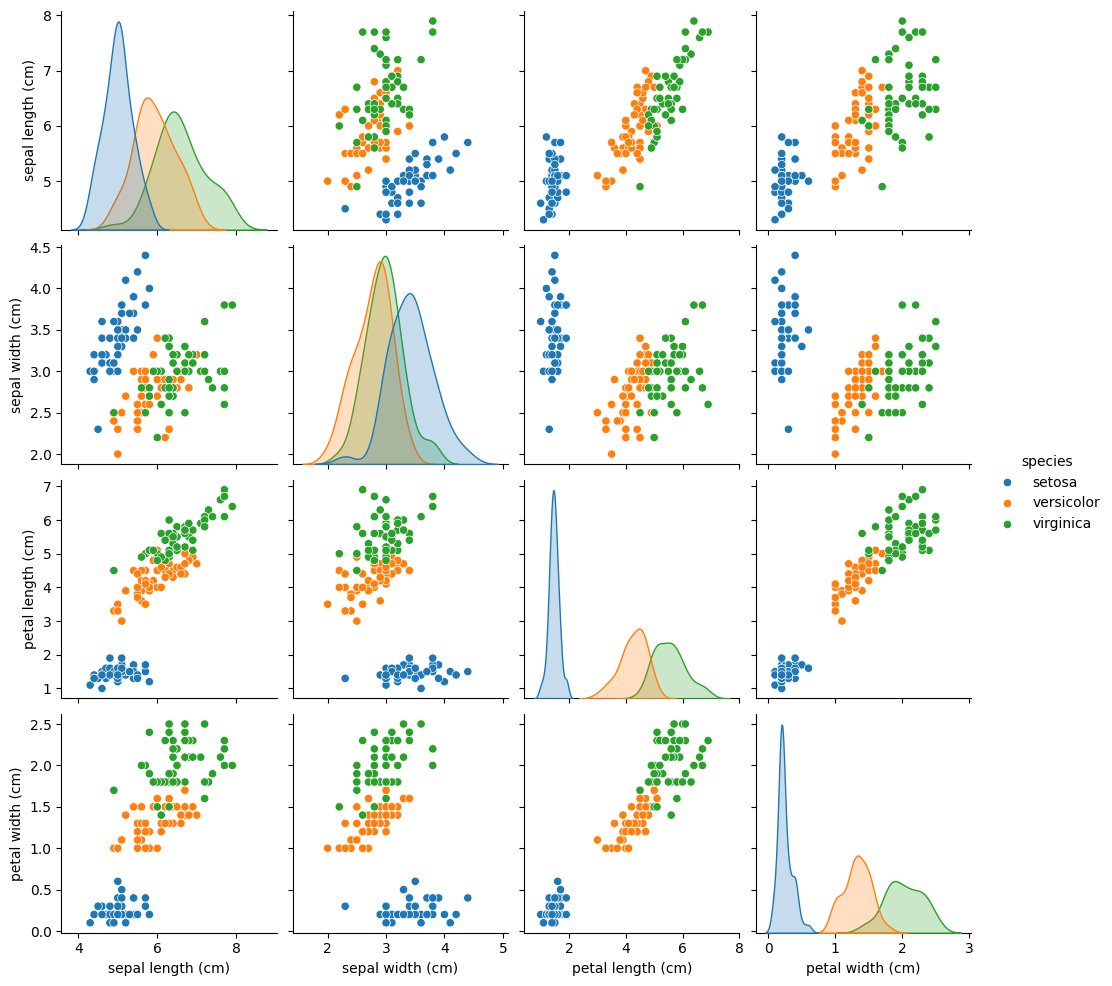

In [27]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="kde"
)

plt.show()

### What should we look for?

For each pair of features, ask:

- Is there a positive or negative association?
- Is the relationship roughly linear?
- Do the classes overlap?
- Are some features much more discriminative than others?
- Are there unusual observations?

For Iris, petal measurements visually separate the species much more clearly than sepal measurements.

This is an **EDA hypothesis**, not yet a formal model result.

# Part IV — Correlation

## 7. Correlation matrix

Pearson correlation measures **linear association** between two numerical variables.

Values close to:

- `+1`: strong positive linear association;
- `-1`: strong negative linear association;
- `0`: weak linear association.

A correlation close to zero does **not** imply independence.

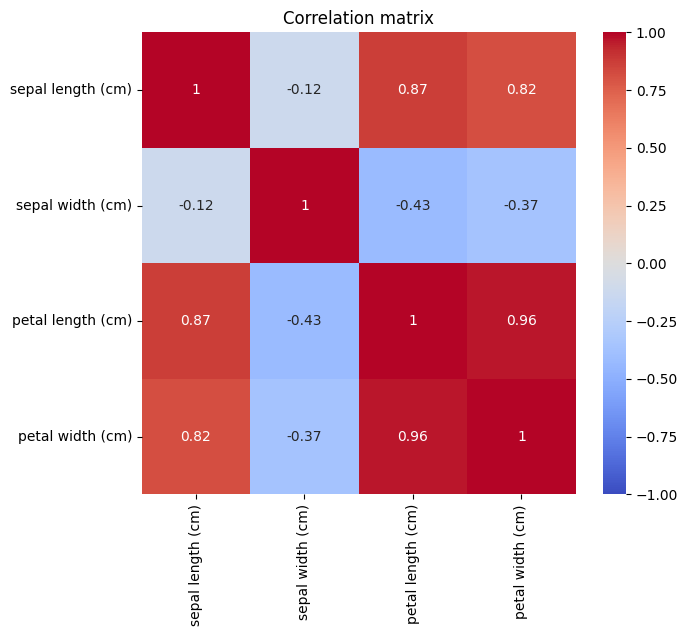

In [28]:
corr = df[iris.feature_names].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation matrix")
plt.show()

### Important interpretation point

Correlation is useful for detecting redundant or strongly related features, but:

- it only captures linear association;
- it does not establish causality;
- it does not tell us whether a variable is useful for prediction by itself;
- a nonlinear dependence may exist even when correlation is near zero.

# Part V — Compare groups explicitly

## 8. Class-wise distributions

Instead of only looking at global distributions, compare groups directly.

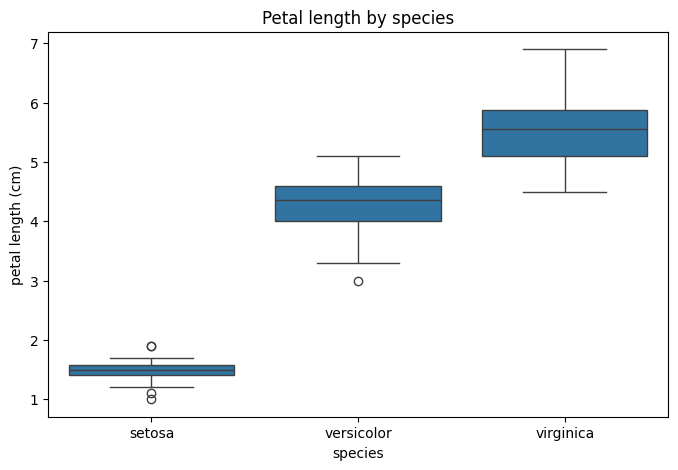

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)"
)

plt.title("Petal length by species")
plt.show()

Now the question becomes:

> Does the distribution of a feature differ systematically across classes?

This type of plot helps us generate hypotheses about which variables might be informative for classification.

## 9. From visualization to hypotheses

At this point, a good EDA should produce statements such as:

- petal length and petal width appear strongly correlated;
- Setosa appears clearly separated from the other species in petal measurements;
- Versicolor and Virginica overlap more;
- sepal width alone appears less discriminative.

These are **descriptive observations**.

The next step could be:

- formal statistical testing;
- feature engineering;
- dimensionality reduction;
- machine learning.

# Part VI — Why dimensionality reduction?

## 10. The problem with many features

With four features, pairplots are still manageable.

But with:

- 10 features, there are 45 pairwise scatter plots;
- 30 features, there are 435;
- 100 features, there are 4,950.

At some point, visualizing every pair is no longer practical.

A dimensionality-reduction method such as **Principal Component Analysis (PCA)** can help summarize multivariate variation using a smaller number of dimensions.

# Part VII — PCA

## 11. What PCA does

PCA constructs new variables called **principal components**.

Each principal component is a linear combination of the original features.

The first component is chosen to capture as much variance as possible.

The second component captures as much of the remaining variance as possible while being orthogonal to the first, and so on.

Conceptually:

```text
Original features
x1, x2, x3, x4
        ↓
      PCA
        ↓
PC1, PC2, PC3, PC4
```

The components are not selected because they predict the class label.

PCA is **unsupervised**: it only looks at the geometry and variance of the features.

## 12. Why standardize before PCA?

PCA is sensitive to scale.

If one variable varies between `0–1` and another between `0–10,000`, the second variable may dominate simply because its numerical scale is larger.

A common preprocessing step is therefore standardization:

\[
z = \frac{x - \mu}{\sigma}
\]

After standardization, each feature has approximately:

- mean = 0;
- standard deviation = 1.

In [30]:
X = df[iris.feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(
    X_scaled,
    columns=iris.feature_names
).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## 13. Fit PCA

In [31]:
pca = PCA(n_components=4)

X_pca = pca.fit_transform(
    X_scaled
)

explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

## 14. Explained variance

Each principal component explains a fraction of the total variance.

A useful question is:

> How many components do we need to retain most of the information?

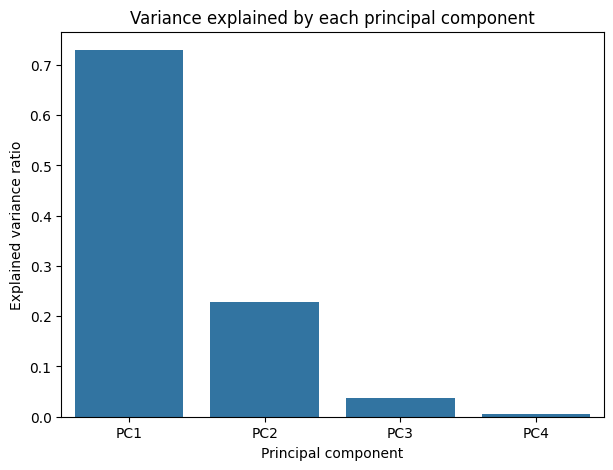

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=[f"PC{i+1}" for i in range(len(explained_variance))],
    y=explained_variance
)

plt.ylabel("Explained variance ratio")
plt.xlabel("Principal component")
plt.title("Variance explained by each principal component")
plt.show()

A second useful view is the **cumulative explained variance**.

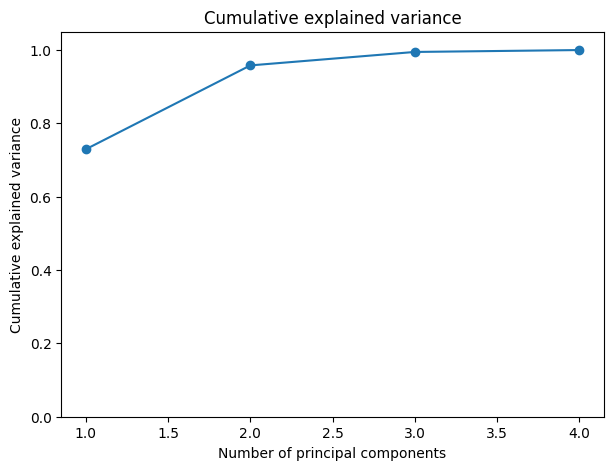

In [33]:
cumulative_variance = np.cumsum(
    explained_variance
)

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.05)
plt.title("Cumulative explained variance")
plt.show()

This plot helps us reason about the trade-off between:

- dimensionality;
- information retained.

# Part VIII — Before and after PCA

## 15. Original feature space

Before PCA, we explore the data through many pairwise projections.

For example:

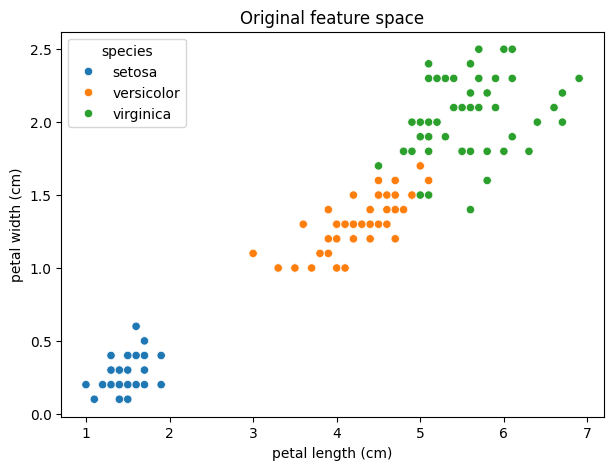

In [34]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species"
)

plt.title("Original feature space")
plt.show()

## 16. PCA projection

Now project the four-dimensional dataset into two dimensions.

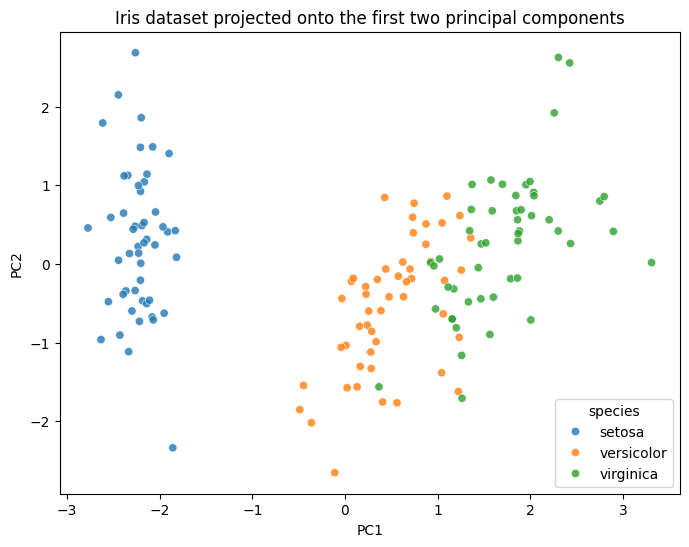

In [35]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

pca_df["species"] = df["species"].values

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    alpha=0.8
)

plt.title("Iris dataset projected onto the first two principal components")
plt.show()

### What changed?

Instead of choosing two original variables, PCA creates two new axes that summarize variation across **all four** original measurements.

This often reveals structure more compactly.

However, PCA does not necessarily maximize class separation.

It maximizes **variance**, not predictive performance.

# Part IX — Interpret the components

## 17. PCA loadings

To understand a principal component, inspect its **loadings**.

A loading tells us how strongly each original feature contributes to a component.

In [36]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=iris.feature_names,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

loadings

,PC1,PC2,PC3,PC4
sepal length (cm),0.521066,0.377418,0.719566,-0.261286
sepal width (cm),-0.269347,0.923296,-0.244382,0.123510
petal length (cm),0.580413,0.024492,-0.142126,0.801449
petal width (cm),0.564857,0.066942,-0.634273,-0.523597


Large absolute values indicate strong contributions.

For example, if petal length and petal width both have large loadings on PC1, PC1 may represent a general **petal-size direction**.

The sign should not be over-interpreted: multiplying an entire principal component by `-1` describes the same PCA solution.

<Figure size 700x500 with 0 Axes>

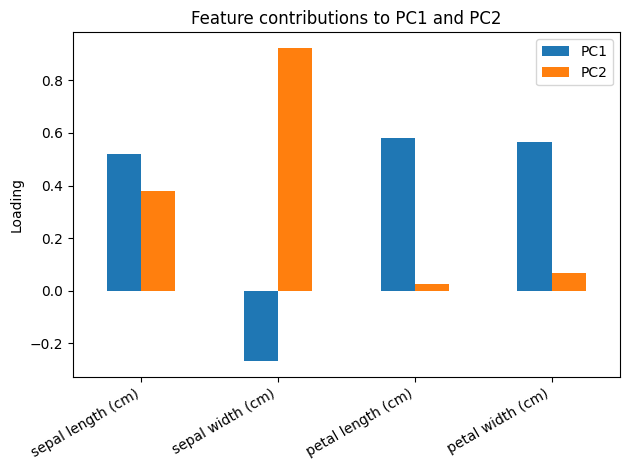

In [37]:
plt.figure(figsize=(7, 5))

loadings[["PC1", "PC2"]].plot(
    kind="bar"
)

plt.ylabel("Loading")
plt.title("Feature contributions to PC1 and PC2")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Part X — EDA is about questions, not plots

## 18. A reusable EDA workflow

A useful general workflow is:

### Step 1 — Understand the dataset

```python
df.head()
df.shape
df.info()
df.describe()
```

### Step 2 — Check data quality

```python
df.isna().sum()
df.duplicated().sum()
```

### Step 3 — Inspect individual variables

Use:

- histograms;
- box plots;
- value counts.

### Step 4 — Study relationships

Use:

- scatter plots;
- pairplots;
- grouped box plots;
- correlation matrices.

### Step 5 — Compare meaningful groups

Ask whether distributions differ between categories or target classes.

### Step 6 — Generate hypotheses

Do not just say:

> "Here is a plot."

Instead ask:

> "What does this plot suggest about the data?"

### Step 7 — Use dimensionality reduction when useful

PCA can summarize a high-dimensional feature space and provide an additional exploratory view.

# Part XI — Practice on another dataset

## 19. Repeat the workflow

Try applying the same EDA workflow to another `scikit-learn` dataset.

Good options include:

### Wine dataset

```python
from sklearn.datasets import load_wine
```

Questions:

- Do the three wine classes show different chemical profiles?
- Which variables appear most discriminative?
- Are some features strongly correlated?
- How many PCA components explain most of the variance?

### Breast Cancer dataset

```python
from sklearn.datasets import load_breast_cancer
```

Questions:

- Which features differ most between the two classes?
- Which measurements are strongly redundant?
- Does a two-dimensional PCA projection show visible class structure?

### Digits dataset

```python
from sklearn.datasets import load_digits
```

Questions:

- How balanced are the digit classes?
- What do average pixel intensities look like?
- Can PCA provide a useful low-dimensional representation of the images?

# Take-home messages

- EDA is a structured process for understanding data.
- Begin with data quality before sophisticated visualization.
- Combine univariate and multivariate views.
- Pairplots are useful for small numbers of features.
- Correlation measures linear association, not independence or causality.
- Comparing groups helps generate hypotheses about discriminative variables.
- PCA summarizes multivariate variance using new orthogonal directions.
- Standardization is usually important before PCA.
- Explained variance tells us how much information each component retains.
- Loadings help interpret principal components.
- PCA is exploratory: it does not automatically prove class separation or predictive relevance.